# Drifting Models: A Step-by-Step Demo

**Paper:** Generative Modeling via Drifting

This demo walks you through the core algorithm with hands-on examples:

1. **Part 1: Core Algorithm** — The drifting loss and drift computation
2. **Part 2: Toy 2D** — Visualize dynamics on swiss roll & checkerboard

**More samples and full results can be found in the paper.**

---

# Install packages

In [1]:
!pip install -q matplotlib numpy torch torchvision tqdm einops

In [2]:
import os
import sys
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Device selection
# - In Colab: prefer CUDA (GPU) and warn if GPU isn't enabled
# - Locally: prefer CUDA, then Apple Silicon MPS, then CPU
IN_COLAB = (
    "google.colab" in sys.modules
    or os.environ.get("COLAB_GPU") is not None
    or os.environ.get("COLAB_TPU_ADDR") is not None
)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif (not IN_COLAB) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE} (IN_COLAB={IN_COLAB})")
if IN_COLAB and DEVICE.type != "cuda":
    print(
        "[Warning] Colab is not running with GPU enabled. Please select 'Runtime -> Change runtime type -> GPU' in the menu and re-run this cell."
    )

Using device: cuda (IN_COLAB=True)


# Part 1: Core Algorithm

**Traditional generative models** (Diffusion, Flow Matching) iterate at **inference time**.

**Drifting Models** move the iteration to **training time**:
- Each training step "drifts" the generated samples according to a drifting field
- At inference: just one forward pass (1 NFE)

## Training Objective

Given a generator $f_\theta$ that maps noise $\epsilon$ to samples, the training loss is:

$$
L = \mathbb{E}_{\epsilon} \Big[ \big\| f_\theta(\epsilon) - \text{stopgrad}\big(f_\theta(\epsilon) + \mathbf{V}_{p,q}(f_\theta(\epsilon))\big) \big\|^2 \Big]
$$

We move predictions toward their **drifted** versions. The drifting field $\mathbf{V}_{p,q}$, depending on the data distribution $p$ and the generated distribution $q$, tells each generated sample where to go. This can be implemented as the following code.

In [3]:
import torch
import torch.nn.functional as F


def compute_V(x, y_pos, y_neg, T):
    """
    Compute the drifting field V based on positive and negative samples.

    x: [N, D] generated samples
    y_pos: [N_pos, D] real/positive samples
    y_neg: [N_neg, D] negative samples (often the same as x)
    T: temperature (tau)
    """
    N = x.shape[0]
    N_pos = y_pos.shape[0]
    N_neg = y_neg.shape[0]

    # compute pairwise distance
    dist_pos = torch.cdist(x, y_pos)  # [N, N_pos]
    dist_neg = torch.cdist(x, y_neg)  # [N, N_neg]

    # ignore self (if y_neg is x)
    # Using a small epsilon to avoid exactly zero distance if not ignoring self
    if x is y_neg or torch.allclose(x, y_neg):
        dist_neg = dist_neg + torch.eye(N, device=x.device) * 1e6

    # compute logits
    logit_pos = -dist_pos / T
    logit_neg = -dist_neg / T

    # concat for normalization
    logit = torch.cat([logit_pos, logit_neg], dim=1)  # [N, N_pos + N_neg]

    # normalize along both dimensions (A_row and A_col in paper)
    A_row = F.softmax(logit, dim=-1)
    A_col = F.softmax(logit, dim=-2)
    A = torch.sqrt(A_row * A_col)

    # back to [N, N_pos] and [N, N_neg]
    A_pos, A_neg = torch.split(A, [N_pos, N_neg], dim=1)

    # compute the weights (W_pos, W_neg in paper)
    W_pos = A_pos  # [N, N_pos]
    W_neg = A_neg  # [N, N_neg]

    # W_pos *= A_neg.sum(dim=1,keepdim=True)
    # W_neg *= A_pos.sum(dim=1,keepdim=True)
    W_pos = W_pos * A_neg.sum(dim=1, keepdim=True)
    W_neg = W_neg * A_pos.sum(dim=1, keepdim=True)

    drift_pos = W_pos @ y_pos  # [N, D]
    drift_neg = W_neg @ y_neg  # [N, D]

    V = drift_pos - drift_neg

    # Debug prints for V computation
    print(f"  [compute_V] drift_pos mean: {drift_pos.mean().item():.6f}, std: {drift_pos.std().item():.6f}")
    print(f"  [compute_V] drift_neg mean: {drift_neg.mean().item():.6f}, std: {drift_neg.std().item():.6f}")
    print(f"  [compute_V] V mean: {V.mean().item():.6f}, max: {V.max().item():.6f}, min: {V.min().item():.6f}")
    return V


def compute_drifting_loss(x, y_pos, y_neg, temperatures=[0.05]):
    """
    Compute aggregated drifting loss over multiple temperatures.
    """
    B, D = x.shape

    # Flatten if needed, but here we expect [B, D] where D is the flattened dimension

    # Feature normalization as per Appendix A.8
    # "Intuitively, we want the average distance to be sqrt(C_j)"
    # dist_j(x, y) = ||phi_j(x) - phi_j(y)|| / S_j
    # S_j = 1/sqrt(C_j) * E[||phi_j(x) - phi_j(y)||]

    # Concatenate all samples for global distance normalization
    all_samples = torch.cat([x, y_pos], dim=0)
    pairwise_dist = torch.cdist(all_samples, all_samples)
    S_j = torch.mean(pairwise_dist)/ (D ** 0.5 + 1e-6)

    print(f"[Drift Loss] Feature Normalization Scale S_j: {S_j.item():.6f}")

    # Normalized samples
    x_norm = x / (S_j.detach() + 1e-6)
    y_pos_norm = y_pos / (S_j.detach() + 1e-6)
    y_neg_norm = y_neg / (S_j.detach() + 1e-6)

    print(f"[Drift Loss] x_norm mean: {x_norm.mean().item():.6f}")

    metrics = {
        "train/drifting_S_j": S_j.item()
    }

    V_total = torch.zeros_like(x)
    for T in temperatures:
        print(f"[Drift Loss] Processing Temperature T={T}")
        # Note: Paper uses T * sqrt(D) for normalized features
        scaled_T = T * (D ** 0.5)
        V_t = compute_V(x_norm, y_pos_norm, y_neg_norm, scaled_T)

        # Drift normalization as per Appendix A.8
        # lambda_j = sqrt( E[ ||V_j||^2 / D ] )
        lambda_j = torch.sqrt(torch.mean(torch.sum(V_t**2, dim=-1)) / D + 1e-6)

        print(f"[Drift Loss] T={T}: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): {lambda_j.item():.6f}")
        metrics[f"train/drifting_lambda_T{T}"] = lambda_j.item()

        V_t = V_t / (lambda_j.detach() + 1e-6)
        V_total = V_total + V_t

    print(f"[Drift Loss] V_total mean: {V_total.mean().item():.6f}, std: {V_total.std().item():.6f}")

    # MSE loss: MSE(phi_j(x) - sg(phi_j(x) + V_j))
    # Note: drifting utility works on normalized features.
    target = (x_norm + V_total).detach()
    loss = F.mse_loss(x_norm, target)
    print(f"[Drift Loss] Final Loss: {loss.item():.6f}")

    return loss, metrics

def drifting_loss(gen: torch.Tensor, pos: torch.Tensor, compute_drift):
    """Drifting loss: MSE(gen, stopgrad(gen + V))."""
    with torch.no_grad():
        V = compute_drift(gen, pos)
        target = (gen + V).detach()
    return F.mse_loss(gen, target)

## Mean-shift Drifting Field

Having described the general training objective, we now describe a concrete instantiation of the drifting field $\mathbf{V}_{p,q}$.

In principle, $\mathbf{V}_{p,q}$ can be a wide range of vector fields, as long as it satisfies $\mathbf{V}_{p,p} = \mathbf{0}$. In this paper, we use an instantiation inspired by **mean-shift**, defined as

$$
\mathbf{V}_{p,q}(\mathbf{x}) := \mathbf{V}_p^{+}(\mathbf{x}) - \mathbf{V}_q^{-}(\mathbf{x}),
$$

where

$$
\mathbf{V}_p^{+}(\mathbf{x}) := \frac{1}{Z_p(\mathbf{x})} \, \mathbb{E}_{\mathbf{y}^{+} \sim p} \big[ k(\mathbf{x}, \mathbf{y}^{+}) (\mathbf{y}^{+} - \mathbf{x}) \big], \quad \mathbf{V}_q^{-}(\mathbf{x}) := \frac{1}{Z_q(\mathbf{x})} \, \mathbb{E}_{\mathbf{y}^{-} \sim q} \big[ k(\mathbf{x}, \mathbf{y}^{-}) (\mathbf{y}^{-} - \mathbf{x}) \big].
$$

The normalizers are

$$
Z_p(\mathbf{x}) := \mathbb{E}_{\mathbf{y}^{+} \sim p} \big[ k(\mathbf{x}, \mathbf{y}^{+}) \big], \quad Z_q(\mathbf{x}) := \mathbb{E}_{\mathbf{y}^{-} \sim q} \big[ k(\mathbf{x}, \mathbf{y}^{-}) \big].
$$

Substituting into $\mathbf{V}_{p,q} = \mathbf{V}_p^{+} - \mathbf{V}_q^{-}$, we obtain the compact form

$$
\mathbf{V}_{p,q}(\mathbf{x}) = \frac{1}{Z_p(\mathbf{x}) Z_q(\mathbf{x})} \, \mathbb{E}_{\mathbf{y}^{+} \sim p, \, \mathbf{y}^{-} \sim q} \big[ k(\mathbf{x}, \mathbf{y}^{+}) \, k(\mathbf{x}, \mathbf{y}^{-}) \, (\mathbf{y}^{+} - \mathbf{y}^{-}) \big].
$$

---

### Implementation (batch-normalized Monte Carlo estimate)

In practice, we approximate the above expectation using mini-batches. Specifically, we use

$$
\mathbf{V}(\mathbf{x}) := \mathbb{E} \big[ K_B(\mathbf{x}, \mathbf{y}^{+}) \, K_B(\mathbf{x}, \mathbf{y}^{-}) \, (\mathbf{y}^{+} - \mathbf{y}^{-}) \big],
$$

where $K_B$ is a **batch-normalized kernel**: the kernel $k$ is normalized over samples in batch $B$.

This construction guarantees $\mathbf{V}_{p,p} = \mathbf{0}$: when $p = q$, the term $(\mathbf{y}^{+} - \mathbf{y}^{-})$ is anti-symmetric and cancels out in expectation. The resulting field can be efficiently estimated via Monte Carlo over mini-batches.

Below is a reference PyTorch-style implementation, where $k(\mathbf{x}, \mathbf{y}) = \exp(-\|\mathbf{x} - \mathbf{y}\| / \tau)$, and $K_B$ implements the normalization across both $\mathbf x$ and $\mathbf y$, since we found it to slightly improve performance.

In [4]:
# ============================================================
# Core: Compute Drift V and Loss (from toy_mean_drift.py)
# ============================================================

def compute_drift(gen: torch.Tensor, pos: torch.Tensor, temp: float = 0.05):
    """
    Compute drift field V with attention-based kernel.

    Args:
        gen: Generated samples [G, D]
        pos: Data samples [P, D]
        temp: Temperature for softmax kernel

    Returns:
        V: Drift vectors [G, D]
    """
    targets = torch.cat([gen, pos], dim=0)
    G = gen.shape[0]

    dist = torch.cdist(gen, targets)
    dist[:, :G].fill_diagonal_(1e6)  # mask self
    kernel = (-dist / temp).exp() # unnormalized kernel

    normalizer = kernel.sum(dim=-1, keepdim=True) * kernel.sum(dim=-2, keepdim=True) # normalize along both dimensions, which we found to slightly improve performance
    normalizer = normalizer.clamp_min(1e-12).sqrt()
    normalized_kernel = kernel / normalizer

    pos_coeff = normalized_kernel[:, G:] * normalized_kernel[:, :G].sum(dim=-1, keepdim=True)
    pos_V = pos_coeff @ targets[G:]
    neg_coeff = normalized_kernel[:, :G] * normalized_kernel[:, G:].sum(dim=-1, keepdim=True)
    neg_V = neg_coeff @ targets[:G]

    return pos_V - neg_V




## Visualize the Drifting Field

Let's see what the drifting field look like for a randomly initialized $q$.

  [compute_V] drift_pos mean: 0.033877, std: 0.318340
  [compute_V] drift_neg mean: 0.025703, std: 0.261239
  [compute_V] V mean: 0.008174, max: 0.230255, min: -0.272685


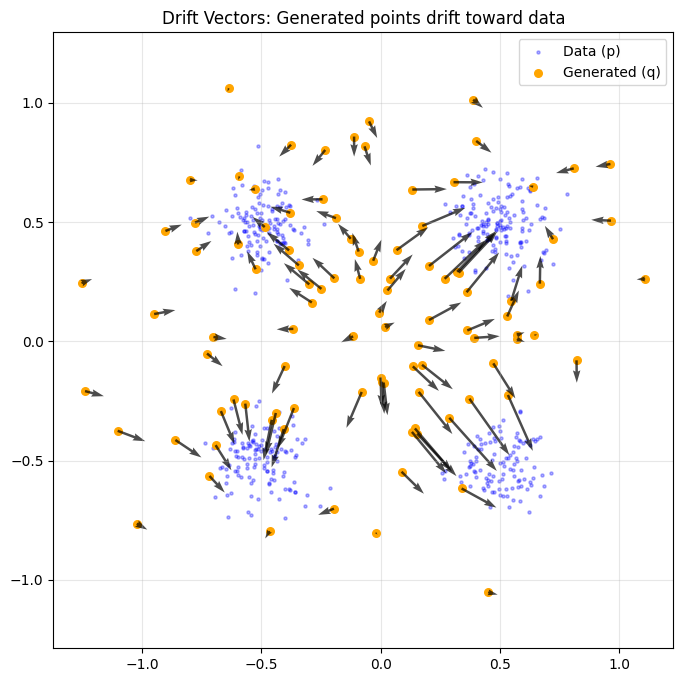

In [5]:
# Quick visualization of drift vectors
torch.manual_seed(42)

# Random generated points (from Gaussian)
gen_test = torch.randn(100, 2) * 0.5

# Target data: simple 4-mode Gaussian mixture
centers = torch.tensor([[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]])
idx = torch.randint(0, 4, (500,))
pos_test = centers[idx] + torch.randn(500, 2) * 0.1

# Compute drift
drift_test = compute_V(gen_test, pos_test, gen_test, 0.2)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(pos_test[:, 0], pos_test[:, 1], s=5, alpha=0.3, c='blue', label='Data (p)')
plt.scatter(gen_test[:, 0], gen_test[:, 1], s=30, c='orange', label='Generated (q)')
plt.quiver(gen_test[:, 0], gen_test[:, 1], drift_test[:, 0], drift_test[:, 1],
           scale=3, color='black', alpha=0.7, width=0.004)
plt.legend()
plt.title('Drift Vectors: Generated points drift toward data')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

---

# Part 2: Toy 2D Examples

Let's train on 2D distributions to visualize the full training dynamics.

We'll use two classic test distributions:
- **Checkerboard**: 4 diagonally-arranged squares (tests mode coverage)
- **Swiss Roll**: Spiral pattern (tests learning complex geometry)

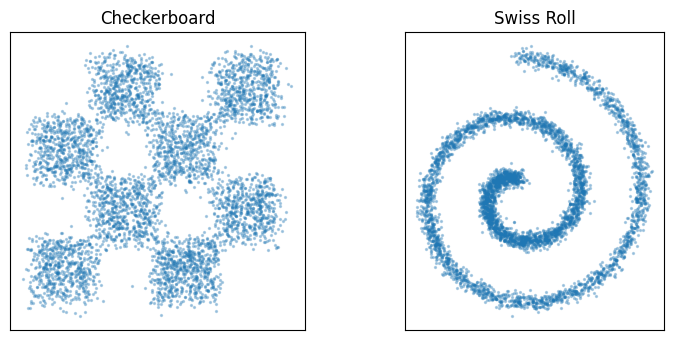

In [6]:
# ============================================================
# Toy Dataset Samplers (minimal; copied from toy_mean_drift.py)
# ============================================================

def sample_checkerboard(n: int, noise: float = 0.05, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    b = torch.randint(0, 2, (n,), generator=g)
    i = torch.randint(0, 2, (n,), generator=g) * 2 + b
    j = torch.randint(0, 2, (n,), generator=g) * 2 + b
    u = torch.rand(n, generator=g)
    v = torch.rand(n, generator=g)
    pts = torch.stack([i + u, j + v], dim=1) - 2.0
    pts = pts / 2.0
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


def sample_swiss_roll(n: int, noise: float = 0.03, seed: int | None = None) -> torch.Tensor:
    g = torch.Generator().manual_seed(seed) if seed is not None else None
    u = torch.rand(n, generator=g)
    t = 0.5 * math.pi + 4.0 * math.pi * u
    pts = torch.stack([t * torch.cos(t), t * torch.sin(t)], dim=1)
    pts = pts / (pts.abs().max() + 1e-8)
    if noise > 0:
        pts = pts + noise * torch.randn(pts.shape, generator=g)
    return pts


# quick look
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, sampler) in zip(axes, [("Checkerboard", sample_checkerboard), ("Swiss Roll", sample_swiss_roll)]):
    pts = sampler(5000).numpy()
    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# Training Loop for Toy 2D
# ============================================================
from functools import partial
class MLP(nn.Module):
    """MLP: noise -> output. 3 hidden layers with SiLU."""
    def __init__(self, in_dim=32, hidden=256, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, z):
        return self.net(z)

def train_toy(sampler, steps=2000, data_batch_size=2048, gen_batch_size=2048, lr=1e-3, temp=0.05,
              in_dim=32, hidden=256, plot_every=500, seed=42):
    """Train drifting model. Returns model and loss history."""
    torch.manual_seed(seed)
    model = MLP(in_dim=in_dim, hidden=hidden, out_dim=2).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ema = None
    pbar = tqdm(range(1, steps + 1))
    for step in pbar:
        pos = sampler(data_batch_size).to(DEVICE)
        gen = model(torch.randn(gen_batch_size, in_dim, device=DEVICE))
        loss, metrics = compute_drifting_loss(gen, pos, gen, temperatures=[temp])

        opt.zero_grad()
        loss.backward()
        opt.step()

        loss_history.append(loss.item())
        ema = loss.item() if ema is None else 0.96 * ema + 0.04 * loss.item()
        pbar.set_postfix(loss=f"{ema:.2e}")

        if step % plot_every == 0 or step == 1:
            with torch.no_grad():
                vis = model(torch.randn(5000, in_dim, device=DEVICE)).cpu().numpy()
                gt = sampler(5000).numpy()
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
            ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
            ax1.set_title('Target'); ax1.set_aspect('equal'); ax1.axis('off')
            ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
            ax2.set_title(f'Generated (step {step})'); ax2.set_aspect('equal'); ax2.axis('off')
            plt.tight_layout(); plt.show()

    return model, loss_history

Training on Swiss Roll...


  0%|          | 0/2000 [00:00<?, ?it/s]

[Drift Loss] Feature Normalization Scale S_j: 0.345816
[Drift Loss] x_norm mean: -0.023757
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.000230, std: 0.001821
  [compute_V] drift_neg mean: -0.000180, std: 0.000145
  [compute_V] V mean: -0.000050, max: 0.006823, min: -0.007244
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.002182
[Drift Loss] V_total mean: -0.022792, std: 0.888161
[Drift Loss] Final Loss: 0.789157


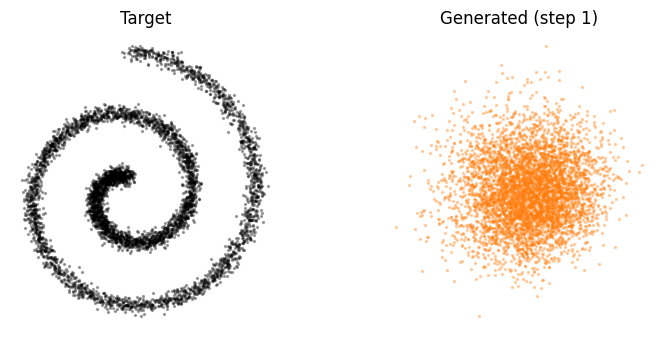

[Drift Loss] Feature Normalization Scale S_j: 0.338084
[Drift Loss] x_norm mean: -0.038995
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.000726, std: 0.009107
  [compute_V] drift_neg mean: -0.000969, std: 0.004092
  [compute_V] V mean: 0.000244, max: 0.035227, min: -0.039101
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.005261
[Drift Loss] V_total mean: 0.046291, std: 0.980610
[Drift Loss] Final Loss: 0.963503
[Drift Loss] Feature Normalization Scale S_j: 0.357038
[Drift Loss] x_norm mean: -0.054714
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.003959, std: 0.024241
  [compute_V] drift_neg mean: -0.003748, std: 0.020129
  [compute_V] V mean: -0.000211, max: 0.015772, min: -0.036625
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.005892
[Drift Loss] V_total mean: -0.035813, std: 0.984796
[Drift Loss] Final Loss: 0.970869
[Drift Loss] Feature Normalization Scale S

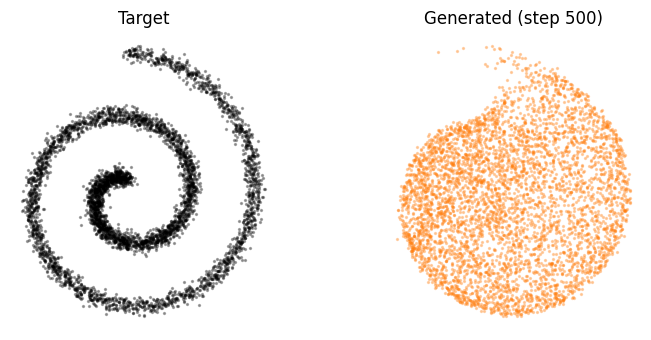

[Drift Loss] Feature Normalization Scale S_j: 0.559992
[Drift Loss] x_norm mean: 0.066893
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: 0.021146, std: 0.361821
  [compute_V] drift_neg mean: 0.021699, std: 0.362377
  [compute_V] V mean: -0.000554, max: 0.090985, min: -0.107362
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.028027
[Drift Loss] V_total mean: -0.019755, std: 0.999254
[Drift Loss] Final Loss: 0.998656
[Drift Loss] Feature Normalization Scale S_j: 0.555907
[Drift Loss] x_norm mean: 0.074948
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: 0.022637, std: 0.365702
  [compute_V] drift_neg mean: 0.021943, std: 0.365165
  [compute_V] V mean: 0.000694, max: 0.083121, min: -0.089187
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.025966
[Drift Loss] V_total mean: 0.026740, std: 0.998984
[Drift Loss] Final Loss: 0.998440
[Drift Loss] Feature Normalization Scale S_j: 0.

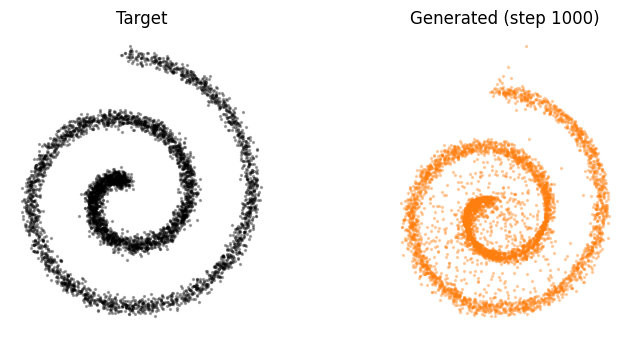

[Drift Loss] Feature Normalization Scale S_j: 0.549773
[Drift Loss] x_norm mean: 0.063973
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: 0.026194, std: 0.387457
  [compute_V] drift_neg mean: 0.029769, std: 0.388067
  [compute_V] V mean: -0.003575, max: 0.023948, min: -0.041286
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.009718
[Drift Loss] V_total mean: -0.367873, std: 0.924168
[Drift Loss] Final Loss: 0.989208
[Drift Loss] Feature Normalization Scale S_j: 0.545237
[Drift Loss] x_norm mean: 0.056043
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: 0.019456, std: 0.388082
  [compute_V] drift_neg mean: 0.019715, std: 0.384795
  [compute_V] V mean: -0.000259, max: 0.029352, min: -0.024036
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.008310
[Drift Loss] V_total mean: -0.031181, std: 0.992245
[Drift Loss] Final Loss: 0.985281
[Drift Loss] Feature Normalization Scale S_j: 

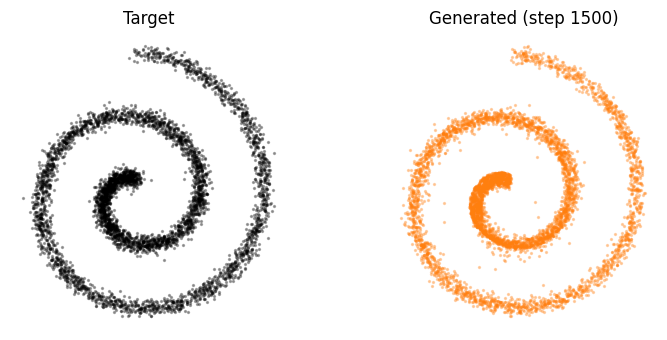

[Drift Loss] Feature Normalization Scale S_j: 0.544982
[Drift Loss] x_norm mean: 0.057504
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: 0.032323, std: 0.387965
  [compute_V] drift_neg mean: 0.032258, std: 0.392232
  [compute_V] V mean: 0.000065, max: 0.024681, min: -0.033717
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.007909
[Drift Loss] V_total mean: 0.008176, std: 0.991935
[Drift Loss] Final Loss: 0.983762
[Drift Loss] Feature Normalization Scale S_j: 0.536889
[Drift Loss] x_norm mean: 0.037947
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: 0.025736, std: 0.394341
  [compute_V] drift_neg mean: 0.025799, std: 0.394957
  [compute_V] V mean: -0.000063, max: 0.018466, min: -0.024222
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.006259
[Drift Loss] V_total mean: -0.009996, std: 0.987066
[Drift Loss] Final Loss: 0.974161
[Drift Loss] Feature Normalization Scale S_j: 0.

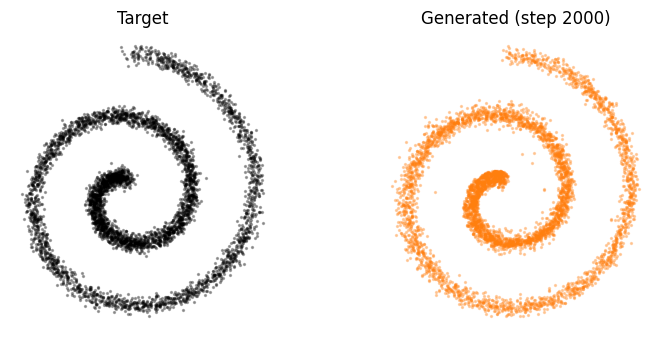

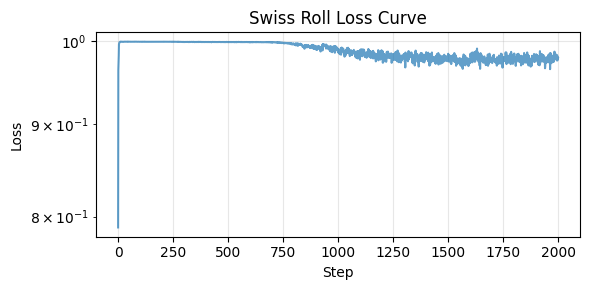

In [8]:
# Train on Swiss Roll
print("Training on Swiss Roll...")
model_swiss, loss_swiss = train_toy(sample_swiss_roll, steps=2000, lr=1e-3, temp=0.05)

plt.figure(figsize=(6, 3))
plt.plot(loss_swiss, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Swiss Roll Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()



Training on Checkerboard...


  0%|          | 0/2000 [00:00<?, ?it/s]

[Drift Loss] Feature Normalization Scale S_j: 0.464711
[Drift Loss] x_norm mean: -0.017679
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.000110, std: 0.000476
  [compute_V] drift_neg mean: -0.000138, std: 0.000107
  [compute_V] V mean: 0.000027, max: 0.002303, min: -0.002218
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.001117
[Drift Loss] V_total mean: 0.024468, std: 0.444345
[Drift Loss] Final Loss: 0.197993


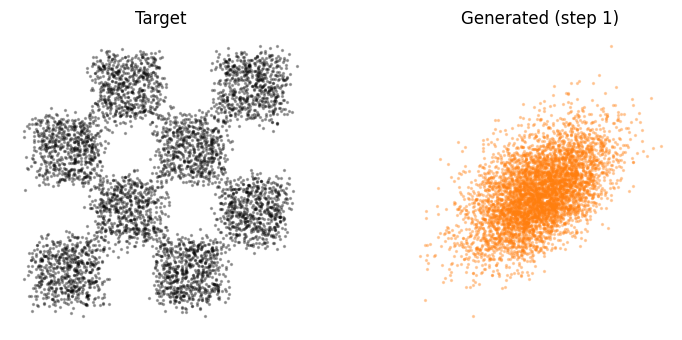

[Drift Loss] Feature Normalization Scale S_j: 0.464170
[Drift Loss] x_norm mean: -0.018489
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.000523, std: 0.002223
  [compute_V] drift_neg mean: -0.000222, std: 0.000922
  [compute_V] V mean: -0.000301, max: 0.010779, min: -0.012692
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.002086
[Drift Loss] V_total mean: -0.144268, std: 0.865363
[Drift Loss] Final Loss: 0.769484
[Drift Loss] Feature Normalization Scale S_j: 0.469963
[Drift Loss] x_norm mean: -0.052242
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.001668, std: 0.009117
  [compute_V] drift_neg mean: -0.001371, std: 0.004837
  [compute_V] V mean: -0.000296, max: 0.059475, min: -0.073373
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.004950
[Drift Loss] V_total mean: -0.059884, std: 0.977469
[Drift Loss] Final Loss: 0.958799
[Drift Loss] Feature Normalization Scale

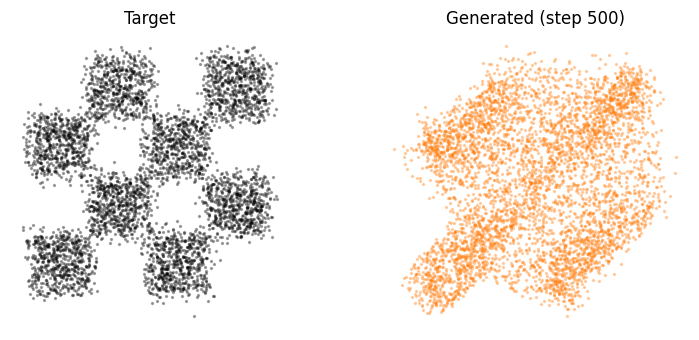

[Drift Loss] Feature Normalization Scale S_j: 0.739913
[Drift Loss] x_norm mean: -0.020538
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.005104, std: 0.374332
  [compute_V] drift_neg mean: -0.005942, std: 0.373845
  [compute_V] V mean: 0.000838, max: 0.043828, min: -0.052358
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.015128
[Drift Loss] V_total mean: 0.055386, std: 0.996330
[Drift Loss] Final Loss: 0.995499
[Drift Loss] Feature Normalization Scale S_j: 0.730949
[Drift Loss] x_norm mean: -0.016560
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.003126, std: 0.367695
  [compute_V] drift_neg mean: -0.003565, std: 0.366820
  [compute_V] V mean: 0.000439, max: 0.047184, min: -0.062190
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.015663
[Drift Loss] V_total mean: 0.028014, std: 0.997625
[Drift Loss] Final Loss: 0.995797
[Drift Loss] Feature Normalization Scale S_j

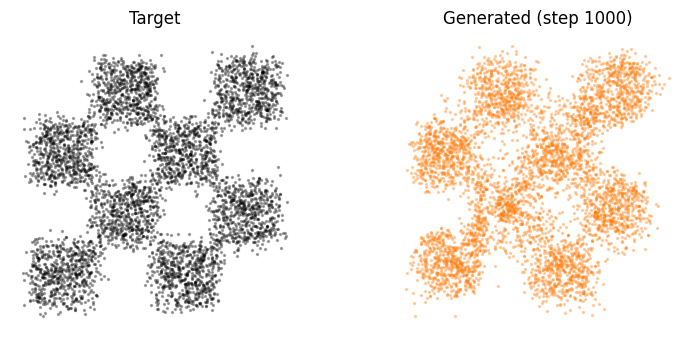

[Drift Loss] Feature Normalization Scale S_j: 0.737460
[Drift Loss] x_norm mean: -0.000574
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.001316, std: 0.377594
  [compute_V] drift_neg mean: -0.003105, std: 0.377532
  [compute_V] V mean: 0.001789, max: 0.035877, min: -0.037187
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.010303
[Drift Loss] V_total mean: 0.173622, std: 0.980040
[Drift Loss] Final Loss: 0.990388
[Drift Loss] Feature Normalization Scale S_j: 0.732018
[Drift Loss] x_norm mean: -0.053485
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.015585, std: 0.378706
  [compute_V] drift_neg mean: -0.017727, std: 0.379540
  [compute_V] V mean: 0.002142, max: 0.034983, min: -0.025860
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.009232
[Drift Loss] V_total mean: 0.231957, std: 0.966684
[Drift Loss] Final Loss: 0.988053
[Drift Loss] Feature Normalization Scale S_j

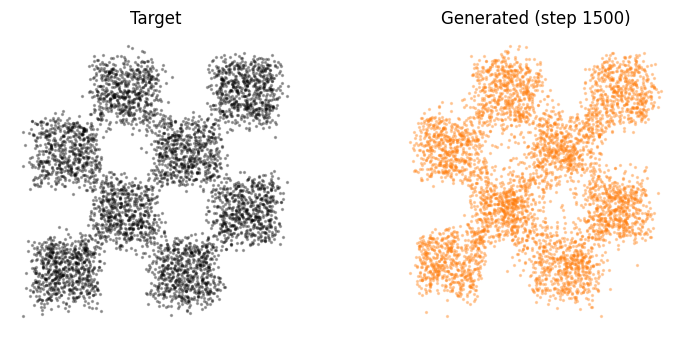

[Drift Loss] Feature Normalization Scale S_j: 0.726194
[Drift Loss] x_norm mean: -0.036383
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.011750, std: 0.383507
  [compute_V] drift_neg mean: -0.012709, std: 0.382333
  [compute_V] V mean: 0.000959, max: 0.033129, min: -0.027705
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.008987
[Drift Loss] V_total mean: 0.106691, std: 0.988056
[Drift Loss] Final Loss: 0.987399
[Drift Loss] Feature Normalization Scale S_j: 0.739269
[Drift Loss] x_norm mean: -0.015812
[Drift Loss] Processing Temperature T=0.05
  [compute_V] drift_pos mean: -0.004764, std: 0.374733
  [compute_V] drift_neg mean: -0.005415, std: 0.374451
  [compute_V] V mean: 0.000651, max: 0.025446, min: -0.030184
[Drift Loss] T=0.05: lambda_j (Drift Magnitude - TRACK THIS FOR CONVERGENCE): 0.008492
[Drift Loss] V_total mean: 0.076654, std: 0.990082
[Drift Loss] Final Loss: 0.985899
[Drift Loss] Feature Normalization Scale S_j

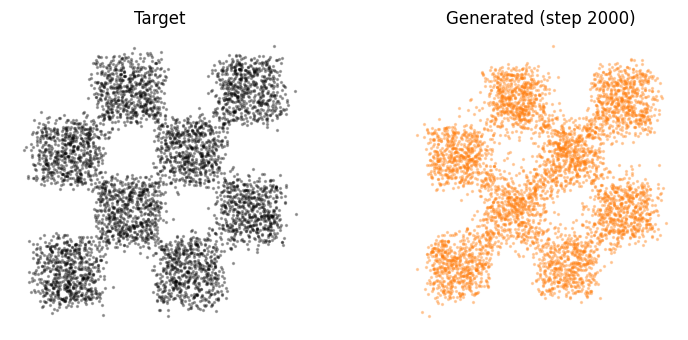

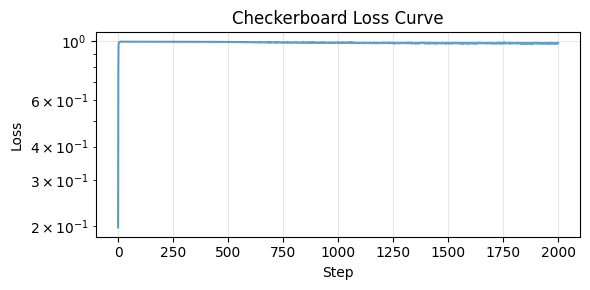

In [9]:

# Train on Checkerboard
print("\nTraining on Checkerboard...")
model_checker, loss_checker = train_toy(sample_checkerboard, steps=2000, lr=1e-3, temp=0.05)

plt.figure(figsize=(6, 3))
plt.plot(loss_checker, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Checkerboard Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()